In [ ]:
import requests
import pandas as pd

# 1) Endereço da API (endpoint)
url = "https://api.open-meteo.com/v1/forecast"

# 2) As 10 variáveis que queremos
variaveis = [
    "temperature_2m",             # temperatura do ar (°C)
    "apparent_temperature",       # sensação térmica (°C)
    "relative_humidity_2m",       # umidade relativa (%)
    "precipitation",              # chuva acumulada na hora (mm)
    "precipitation_probability",  # probabilidade de chuva (%)
    "cloud_cover",                # cobertura de nuvens (%)
    "wind_speed_10m",             # velocidade do vento (km/h)
    "wind_direction_10m",         # direção do vento (°)
    "pressure_msl",               # pressão ao nível do mar (hPa)
    "uv_index",                   # índice UV
]

# 3) Parâmetros da requisição: local, variáveis e fuso horário
params = {
    "latitude": -23.55,           # São Paulo
    "longitude": -46.63,
    "hourly": ",".join(variaveis),
    "timezone": "America/Sao_Paulo",
}

# 4) Chamada à API
resp = requests.get(url, params=params, timeout=10)
resp.raise_for_status()           # para o programa se a API retornar erro
dados = resp.json()               # converte a resposta JSON em dicionário Python

# 5) Transformar em DataFrame
df = pd.DataFrame(dados["hourly"])
df["time"] = pd.to_datetime(df["time"])

# 6) (Opcional) Renomear as colunas para português
df = df.rename(columns={
    "time": "data_hora",
    "temperature_2m": "temperatura",
    "apparent_temperature": "sensacao_termica",
    "relative_humidity_2m": "umidade",
    "precipitation": "chuva_mm",
    "precipitation_probability": "prob_chuva",
    "cloud_cover": "nuvens",
    "wind_speed_10m": "vento_kmh",
    "wind_direction_10m": "vento_direcao",
    "pressure_msl": "pressao",
    "uv_index": "indice_uv",
})

# Exercícios

# 1. Utilizando os dados da API anterior, responda as seguinte perguntas:



# b) Em função da temperatura mediana, crie uma coluna que compara cada linha da coluna temperatura com a temperatura mediana e traga a informação se está abaixo, acima ou igual a mediana.

# c) Plote a temperatura temperatura e sensacao_termica em um unico gráfico.

# d) Foi possível observar as duas colunas em um mesmo gráfico? Ou por causa de alguma coluna, o gráfico ficou achatado?






In [ ]:
# a) Quais os valores médios, medianos, min e max das colunas "temperatura", "sensacao_termica",
# "umidade", "chuva_mm". 

def valores():
    
    return print(f"""Temperatura:
    Mínimo: {df["temperatura"].min()}
    Máximo: {df["temperatura"].max()}
    Médio: {round(df["temperatura"].mean(), 2)}
    Mediana: {df["temperatura"].median()}
Sensação Térmica:
    Mínimo: {df["sensacao_termica"].min()}
    Máximo: {df["sensacao_termica"].max()}
    Médio: {round(df["sensacao_termica"].mean(), 2)}
    Mediana: {df["sensacao_termica"].median()}
Umidade:
    Mínimo: {df["umidade"].min()}
    Máximo: {df["umidade"].max()}
    Médio: {round(df["umidade"].mean(), 2)}
    Mediana: {df["umidade"].median()}
Chuva:
    Mínimo: {df["chuva_mm"].min()}
    Máximo: {df["chuva_mm"].max()}
    Médio: {round(df["chuva_mm"].mean(), 2)}
    Mediana: {df["chuva_mm"].median()}""")
                
valores()

Temperatura:
    Mínimo: 13.4
    Máximo: 28.5
    Médio: 18.35
    Mediana: 17.45
Sensação Térmica:
    Mínimo: 12.7
    Máximo: 29.0
    Médio: 18.83
    Mediana: 18.05
Umidade:
    Mínimo: 37
    Máximo: 100
    Médio: 81.73
    Mediana: 85.0
Chuva:
    Mínimo: 37
    Máximo: 100
    Médio: 81.73
    Mediana: 85.0


In [58]:
colunas = ["temperatura", "sensacao_termica", "umidade", "chuva_mm"]

funcoes = {
    "min": lambda x: x.min(),
    "max": lambda x: x.max(),
    "mean": lambda x: x.mean(),
    "media": lambda x: x.median()
}

def lambda_temp():

    for coluna in colunas:
        for nome_funcao, funcao in funcoes.items():
            print(f"{nome_funcao}: {funcao(df[coluna])}")

lambda_temp()

min: 13.4
max: 28.5
mean: 18.345238095238095
media: 17.45
min: 12.7
max: 29.0
mean: 18.826190476190476
media: 18.05
min: 37
max: 100
mean: 81.73214285714286
media: 85.0
min: 0.0
max: 6.7
mean: 0.22976190476190478
media: 0.0


In [ ]:
colunas = ["temperatura", "sensacao_termica", "umidade", "chuva_mm"]


# agg = Específico do pandas, permite você chamar funções específicas de estastísitcas 
# [count, mean, min, 25%, 50%, 75%, max, median, std]
df[colunas].agg(["min", "max", "mean", "median"])

,temperatura,sensacao_termica,umidade,chuva_mm
min,13.400000,12.70000,37.000000,0.000000
max,28.500000,29.00000,100.000000,6.700000
mean,18.345238,18.82619,81.732143,0.229762
median,17.450000,18.05000,85.000000,0.000000


In [ ]:
# b) Em função da temperatura mediana, crie uma coluna que compara 
# cada linha da coluna temperatura com a temperatura mediana e traga a informação 
# se está abaixo, acima ou igual a mediana.

def mediana():
    filtro = df["temperatura"].median()

    for i in df["temperatura"]:
        if filtro > i:
            print("Acima")
        elif filtro == i:
            print("Igual")
        elif filtro < i:
            print("Abaixo")

mediana()

Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Abaixo
Abaixo
Abaixo
Abaixo
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Acima
Abaixo
Abaixo
Aba

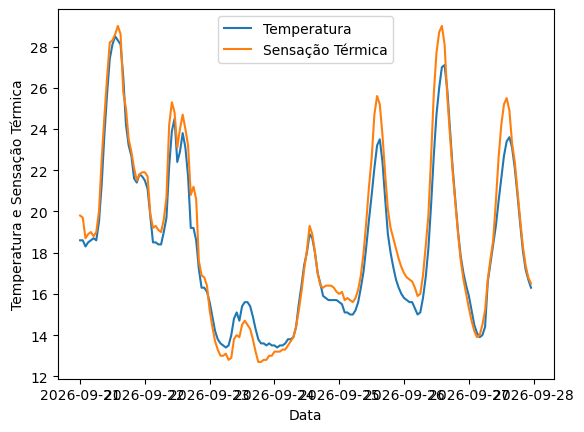

In [56]:
# c) Plote a temperatura e sensacao_termica em um unico gráfico.

import matplotlib.pyplot as plt

x = df["data_hora"]
y1 = df["temperatura"]
y2 = df["sensacao_termica"]


plt.plot(x, y1, x, y2)
plt.xlabel("Data")
plt.ylabel("Temperatura e Sensação Térmica")
plt.legend(["Temperatura", "Sensação Térmica"])
plt.show()
